In [2]:
import numpy as np
import matplotlib.pyplot as plt

from powerxai import shapley_value, owen_value, banzhaf_value, upsilon_value
from utils import PLOT_COLORS

# Ranking Discrepancies

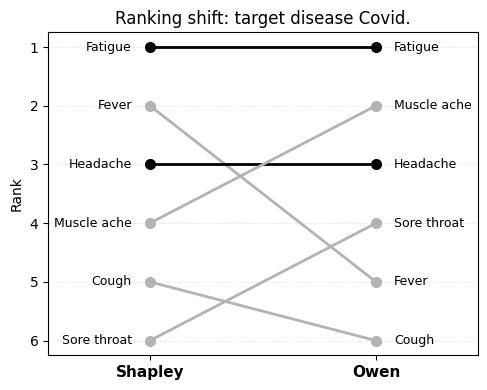

In [ ]:
from disease_model import DiseaseClassificationModel


def probability_of_target(players, coalition_indices):
    symptom_vector = [1 if i in coalition_indices else 0 for i in range(len(model.FEATURE_NAMES))]
    return model.classify(symptom_vector, PRINT=False).probability_of(TARGET_CLASS)

TARGET_CLASS = "Covid"
model = DiseaseClassificationModel()

shapley_scores = np.array([shapley_value(i, model.FEATURE_NAMES, probability_of_target) for i in range(len(model.FEATURE_NAMES))])
shapley_ranking = np.argsort(np.abs(shapley_scores))[::-1]

owen_groups = [["Fever", "Cough", "Headache"], ["Muscle ache", "Sore throat", "Fatigue"]]
owen_scores = np.array([owen_value(i, owen_groups, probability_of_target) for i in range(len(model.FEATURE_NAMES))])
owen_ranking = np.argsort(np.abs(owen_scores))[::-1]

ranks = np.arange(1, len(model.FEATURE_NAMES) + 1)
shapley_rank_by_player = ranks[np.argsort(shapley_ranking)]
owen_rank_by_player = ranks[np.argsort(owen_ranking)]




# PLOT
def rank_chart(players, method_1_rank, method_2_rank, label_1: str, label_2: str, label_extra: str):
    ### Bump chart
    fig, ax = plt.subplots(figsize=(5, 4))
    for i in range(len(players)):
        rank_changed = method_1_rank[i] != method_2_rank[i]
        color = PLOT_COLORS.GRAY if rank_changed else PLOT_COLORS.BLACK
        ax.plot([0, 1], [method_1_rank[i], method_2_rank[i]], "o-", color=color, alpha=1.0, linewidth=2, markersize=7)
        ax.text(-0.08, method_1_rank[i], players[i], ha="right", va="center", fontsize=9)
        ax.text(1.08, method_2_rank[i], players[i], ha="left", va="center", fontsize=9)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([label_1, label_2], fontsize=11, fontweight="bold")
    ax.set_xlim(-0.45, 1.45)
    ax.invert_yaxis()
    ax.set_yticks(range(1, len(players) + 1))
    ax.set_ylabel("Rank")
    ax.set_title(f"Ranking shift: {label_extra}")
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()
    # fig.savefig("ranking_shift.pdf", bbox_inches="tight")

rank_chart(model.FEATURE_NAMES, shapley_rank_by_player, owen_rank_by_player, "Shapley", "Owen", f"target disease {TARGET_CLASS}.")

# When Group Structure Changes Attribution

In [4]:
from fraud_model import FraudDetectionModel

model = FraudDetectionModel()
TARGET_CLASS = "Account Takeover"
THRESHOLD = 0.5


def all_signals_value(players, coalition_indices):
    flat_players = [player for group in players for player in group] if isinstance(players[0], list) else players
    FEATURE_INDEX = {name: model.FEATURE_NAMES.index(name) for name in flat_players}
    signal_vector = [0] * len(model.FEATURE_NAMES)
    for coalition_index in coalition_indices:
        signal_vector[FEATURE_INDEX[flat_players[coalition_index]]] = 1
    probability = model.classify(signal_vector, PRINT=False).probability_of(TARGET_CLASS)
    return float(probability >= THRESHOLD)


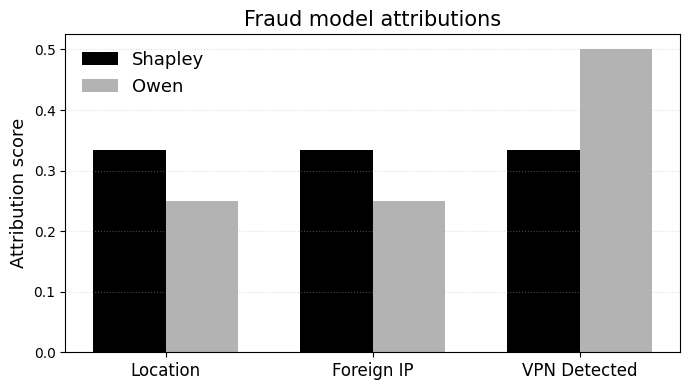

In [9]:
PLAYERS = ["Location", "Foreign IP", "VPN Detected"]

shapley = np.array([shapley_value(i, PLAYERS, all_signals_value) for i in range(len(PLAYERS))])

owen_groups = [["Location", "Foreign IP"], ["VPN Detected"]]
owen = np.array([owen_value(i, owen_groups, all_signals_value) for i in range(len(PLAYERS))])





# PLOT
x, w = np.arange(len(PLAYERS)), 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w / 2, shapley, w, label="Shapley", color=PLOT_COLORS.BLACK)
ax.bar(x + w / 2, owen, w, label="Owen", color=PLOT_COLORS.GRAY)
ax.set_xticks(x)
ax.set_xticklabels(PLAYERS, fontsize=12)
ax.set_ylabel("Attribution score", fontsize=13)
ax.set_title("Fraud model attributions", fontsize=15)
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.legend(frameon=False, fontsize=13)
plt.tight_layout()
# fig.savefig("plot.pdf", bbox_inches="tight")


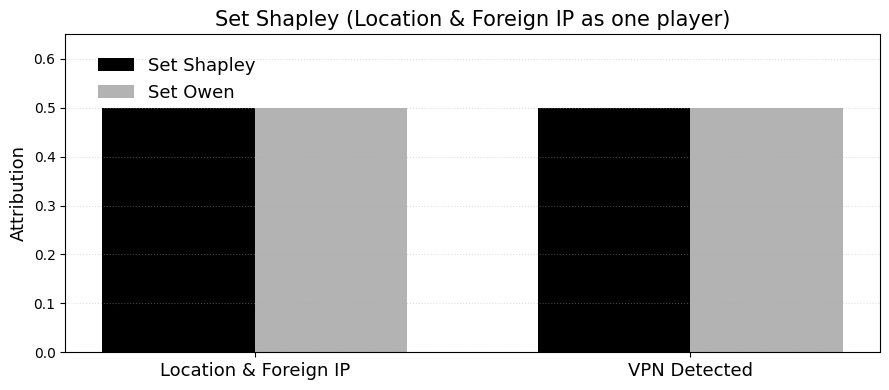

In [11]:
SET_PLAYERS = [["Location & Foreign IP"], ["VPN Detected"]]
META_PLAYER_SIGNALS = {0: ["Location", "Foreign IP"], 1: ["VPN Detected"]}
FEATURE_INDEX = {name: model.FEATURE_NAMES.index(name) for name in model.FEATURE_NAMES}


def set_probability_of_target(players, coalition_indices):
    FEATURE_INDEX = {name: model.FEATURE_NAMES.index(name) for name in model.FEATURE_NAMES}
    signal_vector = [0] * len(model.FEATURE_NAMES)
    for coalition_index in coalition_indices:
        for feature_name in META_PLAYER_SIGNALS[coalition_index]:
            signal_vector[FEATURE_INDEX[feature_name]] = 1
    probability = model.classify(signal_vector, PRINT=False).probability_of(TARGET_CLASS)
    return float(probability >= THRESHOLD)

set_shapley = np.array([shapley_value(i, SET_PLAYERS, set_probability_of_target) for i in range(len(SET_PLAYERS))])
set_owen = np.array([owen_value(i, SET_PLAYERS, set_probability_of_target) for i in range(len(SET_PLAYERS))])






# PLOT
x, w = np.arange(len(SET_PLAYERS)), 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w / 2, set_shapley, w, label="Set Shapley", color=PLOT_COLORS.BLACK)
ax.bar(x + w / 2, set_owen, w, label="Set Owen", color=PLOT_COLORS.GRAY)
ax.set_xticks(x)
ax.set_xticklabels(["Location & Foreign IP", "VPN Detected"], fontsize=13)
ax.set_ylabel("Attribution", fontsize=13)
ax.set_title("Set Shapley (Location & Foreign IP as one player)", fontsize=15)
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.set_ylim(0, max(set_shapley) * 1.30)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.02, 0.98), fontsize=13)
plt.tight_layout()
# fig.savefig("plot.pdf", bbox_inches="tight")


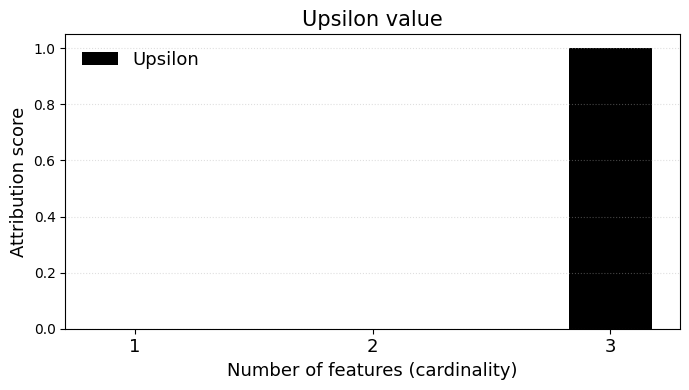

In [ ]:
upsilon = np.array([upsilon_value(cardinality=i+1, players=PLAYERS, value_function=all_signals_value) 
                    for i in range(len(PLAYERS))])




# PLOT
x = np.arange(len(PLAYERS))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x, upsilon, 0.35, label="Upsilon", color=PLOT_COLORS.BLACK)
ax.set_xticks(x)
ax.set_xticklabels([str(i + 1) for i in range(len(PLAYERS))], fontsize=13)
ax.set_xlabel("Number of features (cardinality)", fontsize=13)
ax.set_ylabel("Attribution score", fontsize=13)
ax.set_title("Upsilon value", fontsize=15)
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.legend(frameon=False, fontsize=13)
plt.tight_layout()
# fig.savefig("plot.pdf", bbox_inches="tight")
